### What's up with `T5`s `f_frame` metric on `(2) Random` set?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pretty_midi as pm

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from utils import find_files, get_rgba, pm_apply_sustain_pedal


def plot_custom_piano_roll(ax, pm_true, pm_pred, t_max=30, color_true='tab:blue', color_pred='tab:orange', note_alpha=None):
    import matplotlib

    pm_true = pm_apply_sustain_pedal(pm_true)
    pm_pred = pm_apply_sustain_pedal(pm_pred)

    # piano roll: ground truth
    for note in sum([instr.notes for instr in pm_true.instruments], []):
        ax.add_patch(plt.Rectangle(
            (note.start, note.pitch), note.end - note.start, 1.0, facecolor=get_rgba(color_true, note_alpha or note.velocity / 127.),
            edgecolor='black', linewidth=0.5, linestyle='-', hatch=None))

    # piano roll: transcription
    for note in sum([instr.notes for instr in pm_pred.instruments], []):
        ax.add_patch(plt.Rectangle(
            (note.start, note.pitch), note.end - note.start, 1.0, facecolor=get_rgba(color_pred, note_alpha or note.velocity / 127.),
            edgecolor='black', linewidth=0.0, linestyle='-', hatch=None))

    # axes limits and labels
    ax.set(xlim=(0, t_max), ylim=(pm.note_name_to_number('A0'), pm.note_name_to_number('C8')+1))
    ax.set(xlabel='Time (s)', ylabel='MIDI pitch')

    ## legend patches
    p1 = matplotlib.patches.Patch(facecolor=get_rgba(color_true, 0.5), label='Ground Truth')    
    p2 = matplotlib.patches.Patch(facecolor=get_rgba(color_pred, 0.5), label='T5 transcription')
    ax.legend(handles=[p1, p2], loc='upper right')

In [2]:
path_results = '../results/IRMs'
random_all = f'{path_results}/2_random_all.csv'
df_random = pd.read_csv(random_all)

# extract set of f-score metric columns
columns_fscore = [col for col in df_random.columns if col.startswith('f_')]
print(columns_fscore)
columns_metrics = [col for col in df_random.columns if col.startswith('f_') or col.startswith('p_') or col.startswith('r_')]
print(columns_metrics)

# set ordering of genres and models
genres_order = ['Classical', 'Blues', 'Rock', 'Soul', 'Jazz', 'Latin', 'Pop', 'Country', 'Folk', 'World']
models_order = ['OaF', 'Kong', 'T5', 'Toyama', 'Edwards']
print(genres_order)
print(models_order)

['f_frame', 'f_note_on', 'f_note_on_off', 'f_note_on_vel', 'f_note_on_off_vel']
['p_frame', 'r_frame', 'f_frame', 'p_note_on', 'r_note_on', 'f_note_on', 'p_note_on_off', 'r_note_on_off', 'f_note_on_off', 'p_note_on_vel', 'r_note_on_vel', 'f_note_on_vel', 'p_note_on_off_vel', 'r_note_on_off_vel', 'f_note_on_off_vel']
['Classical', 'Blues', 'Rock', 'Soul', 'Jazz', 'Latin', 'Pop', 'Country', 'Folk', 'World']
['OaF', 'Kong', 'T5', 'Toyama', 'Edwards']


### Metric-specific plotting

In [3]:
df_random_T5 = df_random[df_random['model'] == 'T5']
df_random_T5 = df_random_T5.melt(
    id_vars=['polyphony', 'dynamics', 'piece_id'],
    value_vars=columns_metrics,
    var_name='metric', value_name='value')
type_dict = {'f': 'F1-score', 'p': 'Precision', 'r': 'Recall'}
df_random_T5['type'] = df_random_T5['metric'].apply(lambda x: type_dict[x.split('_')[0]])
df_random_T5['metric'] = df_random_T5['metric'].apply(lambda x: x[2:])
df_random_T5

,polyphony,dynamics,piece_id,metric,value,type
0,1,0,RANDOM_P01_D0,frame,0.118971,Precision
1,1,1,RANDOM_P01_D1,frame,0.189848,Precision
2,1,2,RANDOM_P01_D2,frame,0.127033,Precision
3,2,0,RANDOM_P02_D0,frame,0.220746,Precision
4,2,1,RANDOM_P02_D1,frame,0.118536,Precision
...,...,...,...,...,...,...
1075,23,1,RANDOM_P23_D1,note_on_off_vel,0.026833,F1-score
1076,23,2,RANDOM_P23_D2,note_on_off_vel,0.030342,F1-score
1077,24,0,RANDOM_P24_D0,note_on_off_vel,0.014935,F1-score
1078,24,1,RANDOM_P24_D1,note_on_off_vel,0.027937,F1-score


### Figure 15

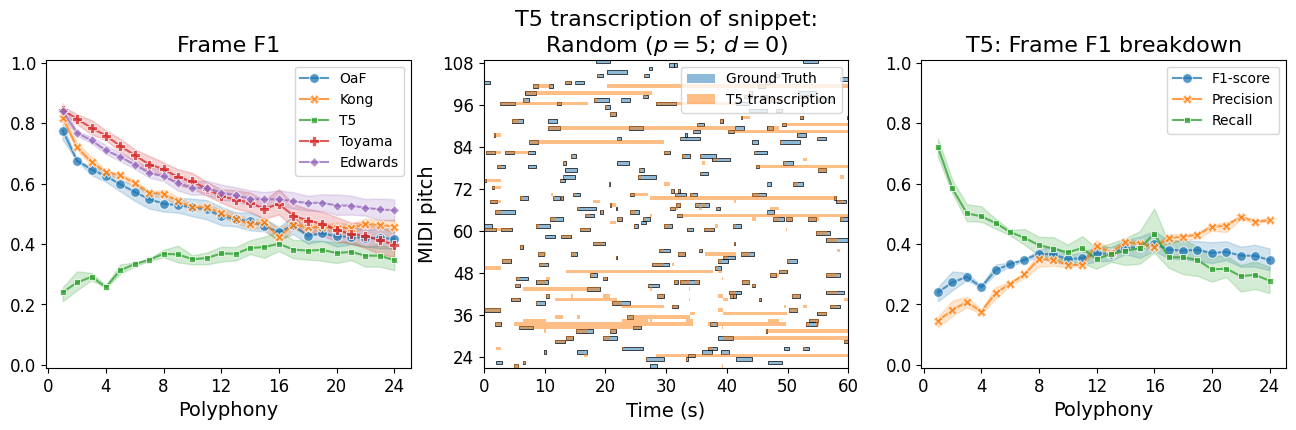

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4), gridspec_kw={'wspace': 0.2})
t_max = 60

# paper revision figure consolidation settings
palette = ['tab10', 'colorblind'][0]
markersize=7 # 6 is the default value
alpha=0.75
fs_title=16
fs_axis=14
fs_ticks=12
rand_ticks = np.arange(0, 25, 4)

# left: Frame F1 system comparison
ax = axs[0]
metric = columns_fscore[0]
sns.lineplot(data=df_random, x='polyphony', y=metric,
            hue='model', hue_order=models_order, style='model',
            markers=True, markersize=markersize, dashes=False, 
            errorbar=('pi', 50), alpha=alpha,
            ax=ax)
ax.legend(loc='upper right')
ax.set_ylim(-0.01, 1.01)
ax.set_ylabel(None)
ax.set_xticks(rand_ticks)
ax.set_title('Frame F1', fontsize=fs_title)
ax.set_xlabel('Polyphony', fontsize=fs_axis)
ax.tick_params(axis='both', labelsize=fs_ticks)

# middle: transcription sample
ax = axs[1]
polyphony = 5
piece_true = pm.PrettyMIDI(find_files('../data/2_random', pattern=f'*_P{polyphony:02d}_D0*.mid')[0])
piece_pred = pm.PrettyMIDI(find_files('../data/dk/2_random_dk', pattern=f'*_P{polyphony:02d}_D0_disklavier_T5.mid')[0])
plot_custom_piano_roll(ax, piece_true, piece_pred, t_max=t_max, note_alpha=0.5)
ax.set_title(f'T5 transcription of snippet:\nRandom ($p = ${polyphony}; $d = $0)', fontsize=fs_title)
ax.set_yticks(np.arange(21+3, 109, 12)) # C2 to C8
ax.set_xlabel(ax.get_xlabel(), fontsize=fs_axis)
ax.set_ylabel(ax.get_ylabel(), fontsize=fs_axis)
ax.tick_params(axis='both', labelsize=fs_ticks)

# right: breakdown of T5's Frame F1-score
ax = axs[2]
metrics_order = ['F1-score', 'Precision', 'Recall']
sns.lineplot(
    ax=ax, data=df_random_T5[df_random_T5['metric'] == 'frame'],
    x='polyphony', y='value',
    hue='type', hue_order=metrics_order,
    style='type', style_order=metrics_order,
    markers=True, markersize=markersize, dashes=False,
    errorbar=('pi', 50), # percentile interval
    err_style=['band', 'bars'][0],
    alpha=alpha
)
ax.legend(loc='upper right')
ax.set_ylim(-0.01, 1.01)
ax.set_ylabel(None)
ax.set_xticks(rand_ticks)
ax.set_title(f'T5: Frame F1 breakdown', fontsize=fs_title)
ax.set_xlabel('Polyphony', fontsize=fs_axis)
ax.tick_params(axis='both', labelsize=fs_ticks)

# fig.savefig('../paper/figs/eval_random_frame_T5_anomaly.pdf', bbox_inches='tight')
plt.show()

# END